folder      : C:\Users\paraj\Documents\bayesian-die-swell-main\datas\infer-oldroyd-rom1\giesekus_lam_5_beta_0p5_alpha_0p1
points      : 124 (thin=2)
curve noise : 2.0% of disp, sigma 0.004108 (realized 0.003224)


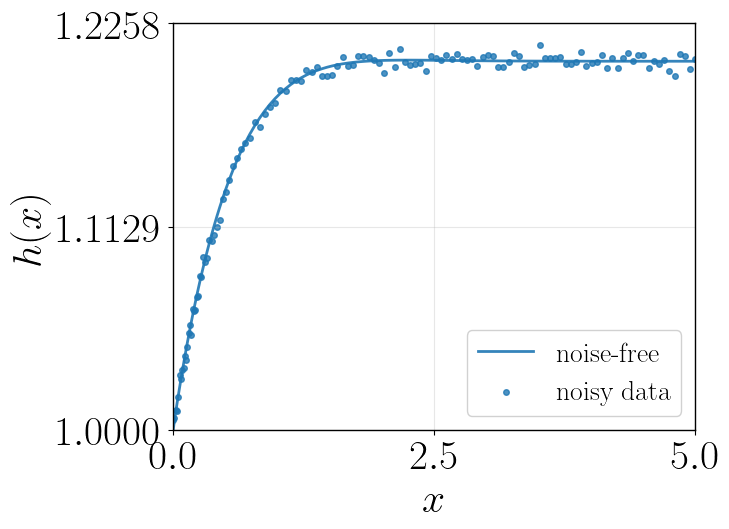

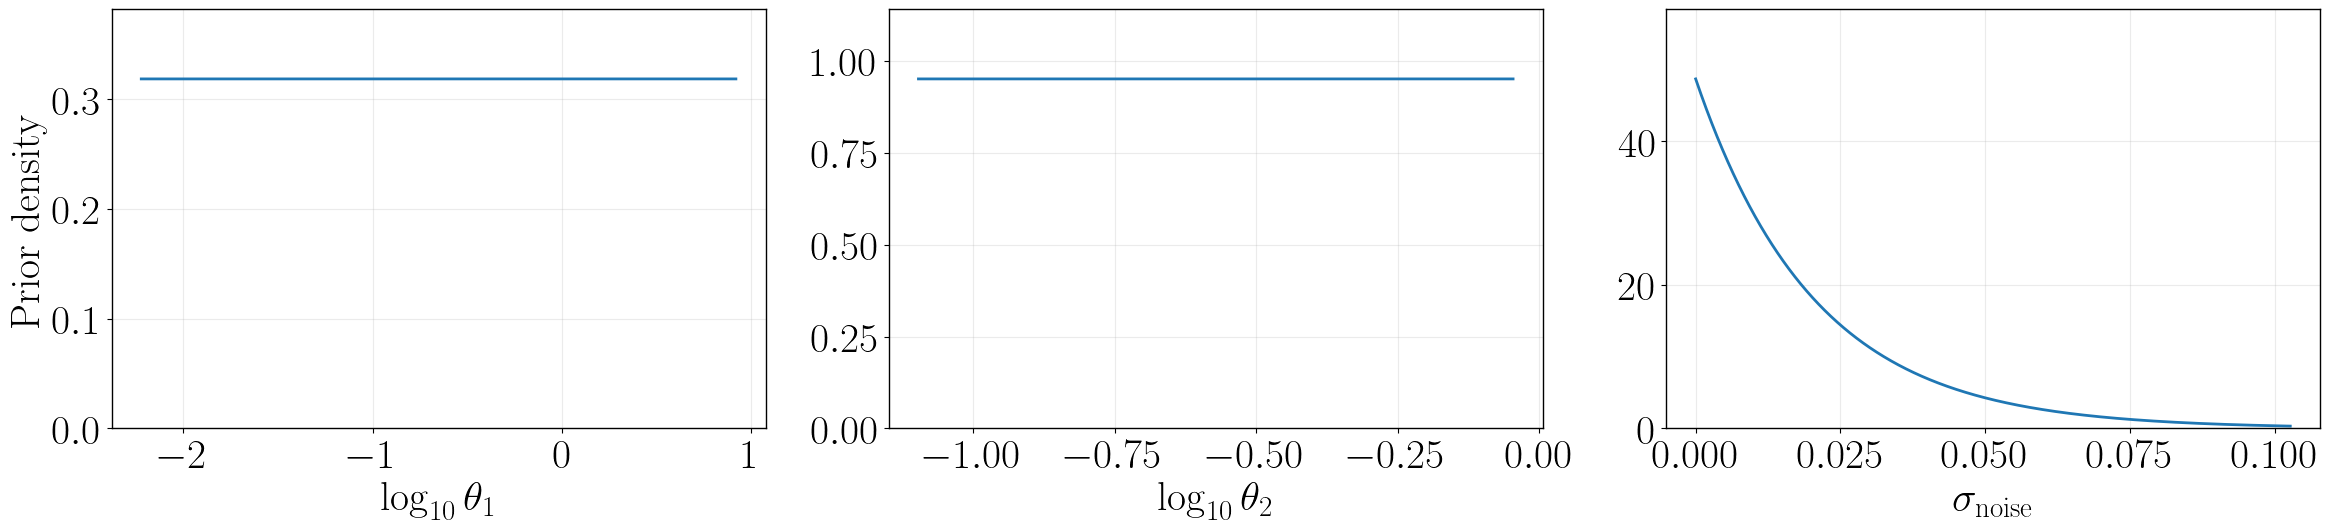

curve4_y GPR on (theta1, theta2), 120 curves: 0.686**2 * RBF(length_scale=[0.0614, 0.391])
parametrize bounds: theta1 (0.005999999999999998, 8.280000000000001), theta2 (0.08, 0.9), implied lambda (0.06, 9.0)
Initial walkers (first 10 of 10, physical space):
          theta1        theta2   sigma_noise
          1.9041       0.47898      0.023096
         0.18796        0.2782      0.020058
        0.017924          0.73      0.024973
          1.6149       0.14803      0.020054
        0.070964       0.73803      0.019116
          4.6639       0.17731      0.015645
         0.53216       0.51644      0.022834
         0.49824       0.14951      0.013556
         0.12086       0.12625      0.028972
        0.062603       0.30664      0.028915


100%|██████████| 2000/2000 [00:04<00:00, 446.03it/s]


Walkers restarted after warm-up (first 10 of 10, physical space):
          theta1        theta2   sigma_noise
          1.5978        0.3667     0.0074046
          1.5225       0.38584     0.0033324
           1.165       0.41966     0.0075497
          1.4971       0.42704     0.0059029
          1.8686       0.39313     0.0024404
           1.221       0.42991     0.0026013
          1.3082       0.38486     0.0062468
          1.6245       0.40612     0.0057082
          2.6375        0.3834    0.00070275
          1.1776       0.41196     0.0094137


100%|██████████| 20000/20000 [00:51<00:00, 388.11it/s]


Parameter              Mean         Std      Rhat     95% CI Low    95% CI High
theta1           1.4460e+00  2.1043e-01     1.192     3.1506e-01     1.5544e+00
theta2           4.0158e-01  8.8595e-02     1.154     3.4154e-01     8.7483e-01
sigma_noise      5.2166e-03  1.0174e-02     1.205     2.9968e-03     5.9621e-02
tau_xy = 0.340388 (R|dp/dx|/2 from pressure_drop.txt, dp/dx = -0.680777), gammadot_w = 0.4, eta0 = tau_xy / gammadot_w = 0.850971
E[N1] (oldroyd) = 0.393749 +/- 0.0573014  (95% CI [0.085795, 0.423284], n=140000)
E[S_R] = 1.15676 +/- 0.168341  (95% CI [0.25205, 1.24353])  E[tau_w] = 0.340388


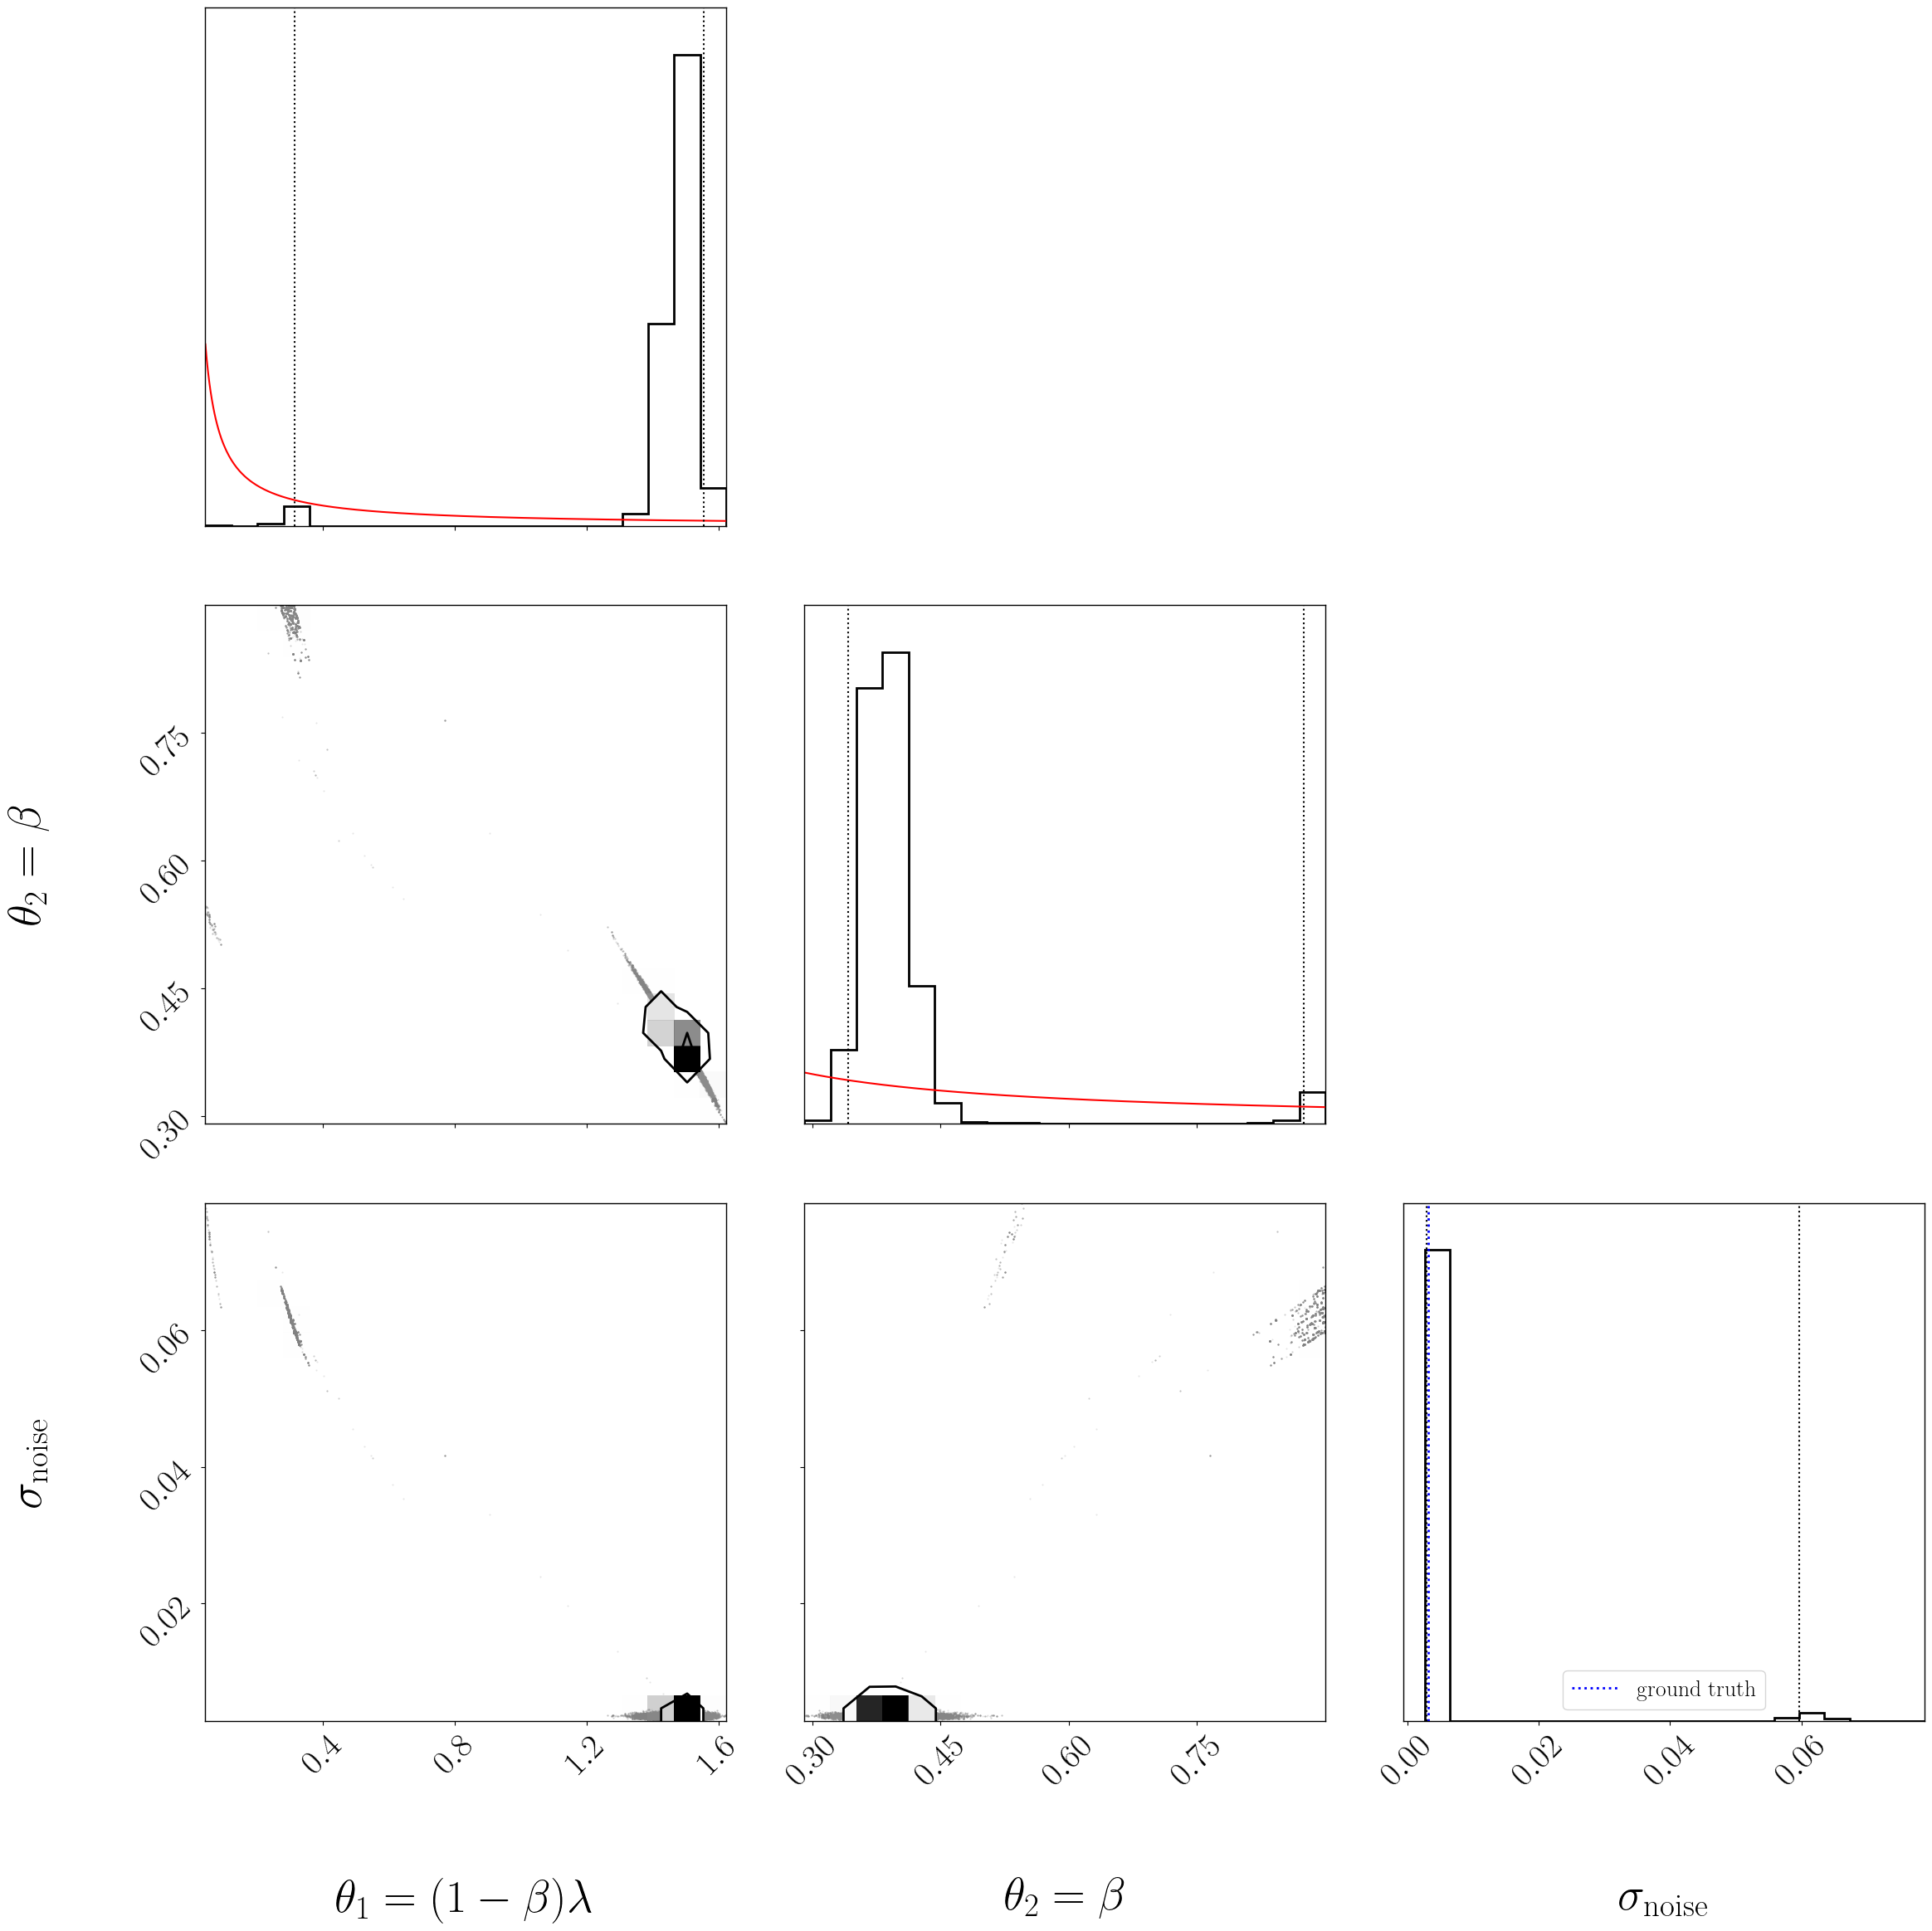

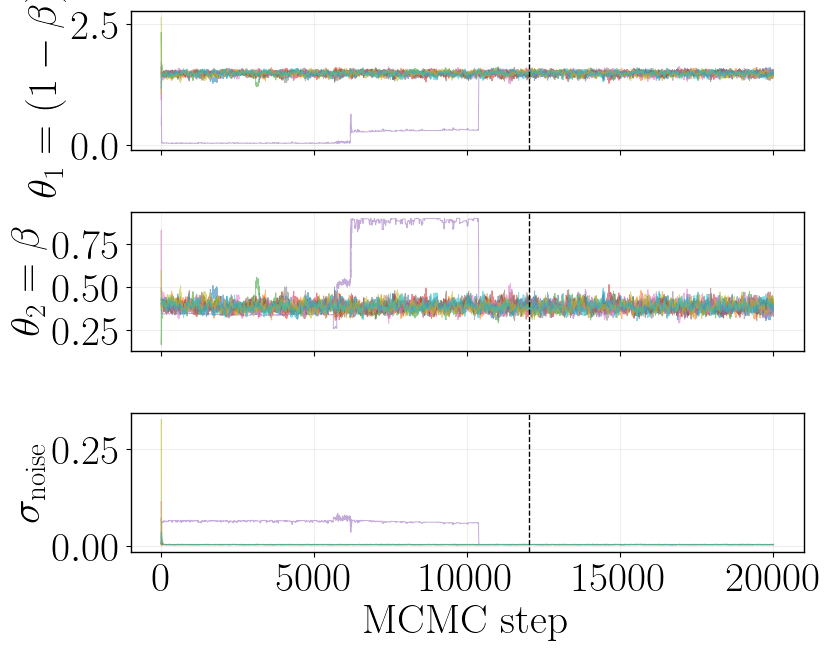


Posterior predictive (95% band)
  coverage=99.2%  rms_z=0.26  max|z|=0.61  mean_z=0.09


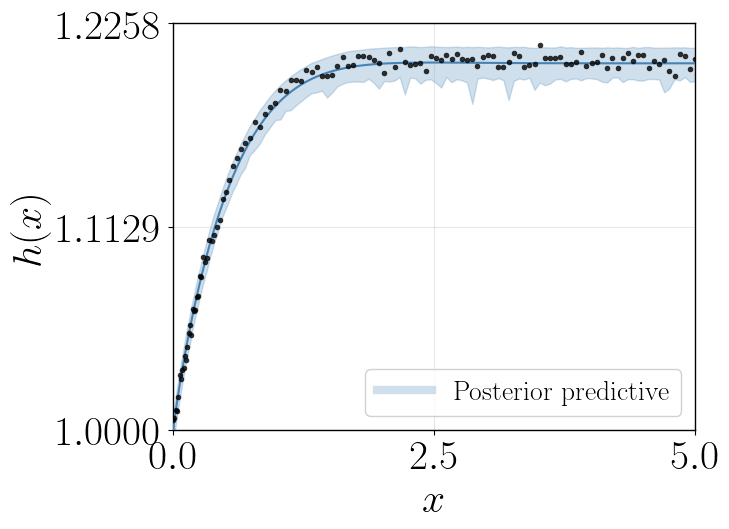

In [ ]:
import sys
import os
from pathlib import Path

CURRENT_DIR = os.getcwd()
FAXEN_ROOT = os.path.abspath(os.path.join(CURRENT_DIR, '..'))
sys.path.append(FAXEN_ROOT)
from packages import ROMCurve4BayesianInference

model = ROMCurve4BayesianInference(
    swell_root=Path(FAXEN_ROOT),
    model="oldroyd",
    parametrize = True,   
    train_data_rels=["datas/oldroyd-rom1"],    
    filenames_train=("curve4_y_all.txt",  "parameters.txt"),  
    lambda_bounds = (0.06, 9.0),
    beta_bounds = (0.08, 0.9),
    sigma_noise_percent=2.0,
    thin=2,
    sigma_bias=None,
    constrained_model_error=True,
    l_bias = 0.51)

model.load_data(filename="datas/infer-oldroyd-rom1/giesekus_lam_5_beta_0p5_alpha_0p1/curve4_y.txt")
model.plot_data()
model.plot_prior()
model.build_rom()
model.run_mcmc(nwalkers=10, nsteps=20000, warmup_fraction=0.2, burn_fraction=0.3)
model.compute_N1(U_avg = 0.1)
model.plot_corner_all()
model.plot_trace_all()
model.plot_posterior_predictive()